### 1) Understanding the Business Case and Domain Analysis.

In [ ]:
# TO House Price Prediction based on Area, Bedrooms, Bathrooms, mainroad, basement, hotwaterheating, airconditioning, parking etc...
# input= Area, Bedrooms, Bathrooms, mainroad, basement, hotwaterheating, airconditioning, parking, furnishingstatus, prefarea
# Target/ouput = Price

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### 2) Data Collection

In [6]:
data = pd.read_csv(r"C:\Users\A susmitha\Downloads\Housing.csv")
data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


### 3) Basic Checks

In [7]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [8]:
data.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [10]:
data.info()
# No missing values in the data.
# no null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### 4) Exploratory Data Analysis

<Axes: xlabel='price', ylabel='Count'>

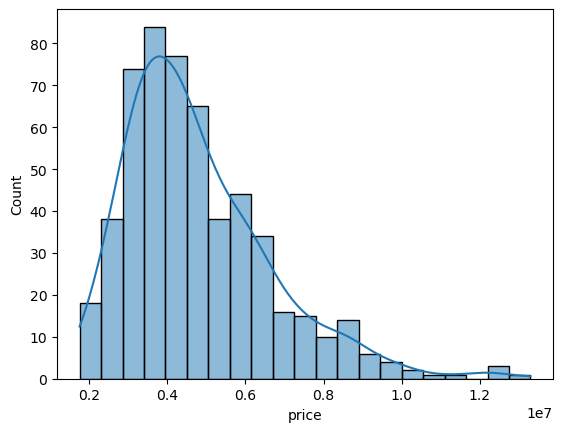

In [11]:
# step 1: Univariate analysis
sns.histplot(x='price', data=data, kde=True)

### 5) Data Cleaning

In [15]:
# step 1: Finding the missing values or null values
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [16]:
# step 2: converting categorical data to numerical
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [21]:
data['furnishingstatus'] = data['furnishingstatus'].map({
    'unfurnished':0,
    'semi-furnished':1,
    'furnished':2
})

In [29]:
data[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']] = \
data[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']].replace({
    'yes':0,
    'no':1,
})

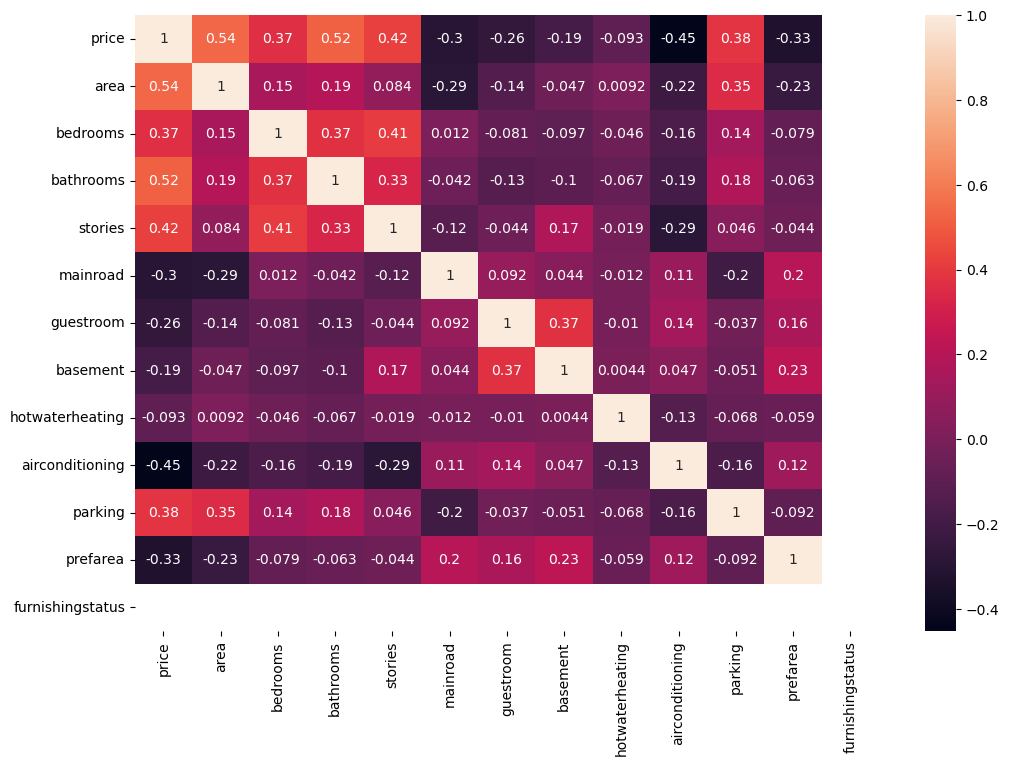

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True)
plt.show()

### 6) Feature Engineering

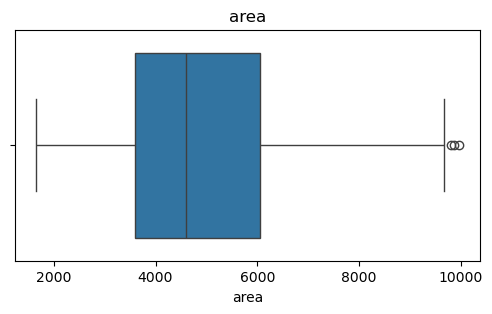

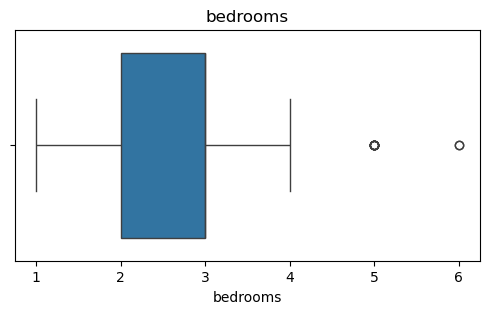

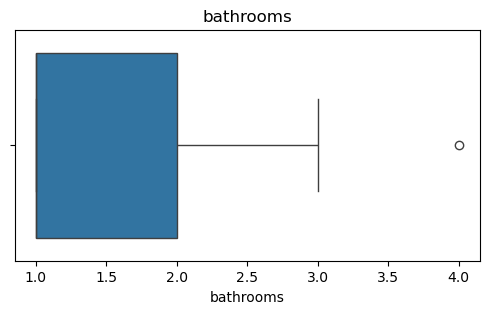

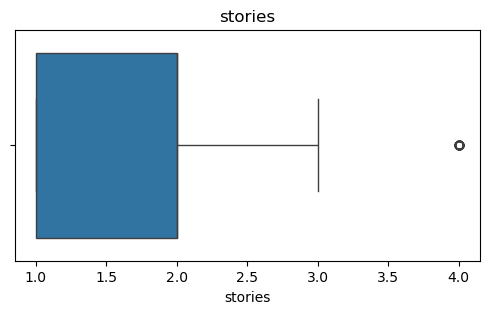

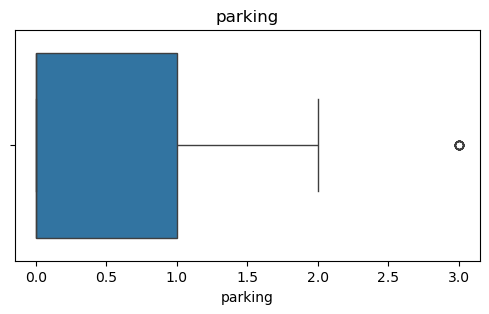

In [50]:
# Step 1: Checking the outlier
num_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [53]:
# step 2: detect the outlliers
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data.loc[data[col] > upper, col] = data[col].median()
    data.loc[data[col] < lower, col] = data[col].median()

### 7) Feature Selection

In [32]:
# stepe 1: create a independent and dependent variable
X = data[["price","bedrooms","bathrooms","stories","parking"]]
y = data["price"]

In [33]:
# step 2: Train and test the model
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [34]:
# step 3: Model Training
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [36]:
# step 4: Prediction
y_pred = lr.predict(X_test)

### 8) Model Evaluation

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))

MAE: 8.351998318225966e-10
MSE: 1.4646676137476195e-18
RMSE: 1.2102345284066305e-09
R2 Score: 1.0


### 9) Actual vs Predicted scatter plot

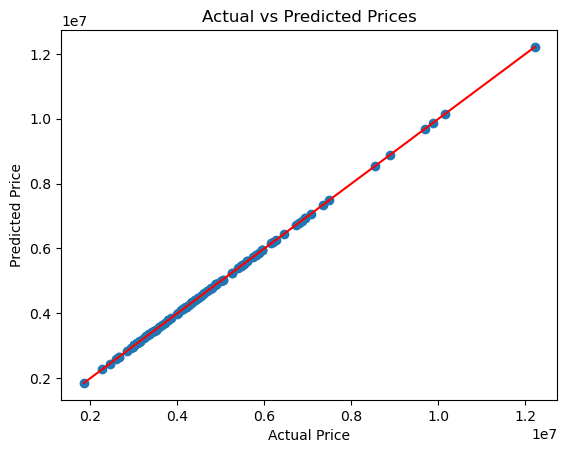

In [54]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

### 10) Model Interpretation

In [57]:
coefficients = pd.DataFrame(lr.coef_, X.columns, columns=['Coefficient'])

print(coefficients)

            Coefficient
price      1.000000e+00
bedrooms   1.042532e-11
bathrooms -3.065279e-11
stories    9.291663e-13
parking   -7.197203e-12


In [58]:
print("\nInsights:")

print("1. Larger house area generally increases house price.")
print("2. More bathrooms and bedrooms contribute to higher property value.")
print("3. Parking availability positively affects house price.")
print("4. The model shows a good relationship between features and house price based on the R2 score.")


Insights:
1. Larger house area generally increases house price.
2. More bathrooms and bedrooms contribute to higher property value.
3. Parking availability positively affects house price.
4. The model shows a good relationship between features and house price based on the R2 score.
